In [1]:
import pandas as pd
import numpy as np

# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "creditcard.csv"

# Load the latest version
df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
  "mlg-ulb/creditcardfraud",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:")
print(df.head())
print(df.shape)

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


First 5 records:
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26    

In [2]:
print('Missing values:', df.isnull().sum().sum())
print('\nDtypes:\n', df.dtypes.value_counts())

Missing values: 0

Dtypes:
 float64    30
int64       1
Name: count, dtype: int64


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [4]:
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [5]:
df['Class'].value_counts(normalize=True)

Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64

In [6]:
df[['Amount', 'Class']].groupby('Class').mean()

,Amount
Class,
0,88.291022
1,122.211321


In [7]:
print("\n" + "-"*80)
print("Statistical Summary:")
print("-"*80)
print(df.describe())


--------------------------------------------------------------------------------
Statistical Summary:
--------------------------------------------------------------------------------
                Time            V1            V2            V3            V4  \
count  284807.000000  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean    94813.859575  1.175161e-15  3.384974e-16 -1.379537e-15  2.094852e-15   
std     47488.145955  1.958696e+00  1.651309e+00  1.516255e+00  1.415869e+00   
min         0.000000 -5.640751e+01 -7.271573e+01 -4.832559e+01 -5.683171e+00   
25%     54201.500000 -9.203734e-01 -5.985499e-01 -8.903648e-01 -8.486401e-01   
50%     84692.000000  1.810880e-02  6.548556e-02  1.798463e-01 -1.984653e-02   
75%    139320.500000  1.315642e+00  8.037239e-01  1.027196e+00  7.433413e-01   
max    172792.000000  2.454930e+00  2.205773e+01  9.382558e+00  1.687534e+01   

                 V5            V6            V7            V8            V9  \
count  2.848070e

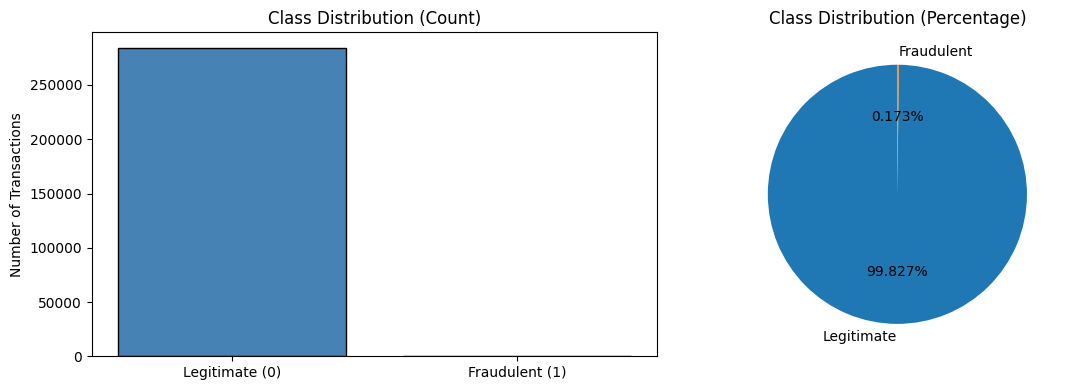

Legitimate: 284315
Fraudulent: 492
Imbalance Ratio (Legit : Fraud) = 578.0


In [8]:
import matplotlib.pyplot as plt

# Count class distribution
class_counts = df['Class'].value_counts()

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
axes[0].bar(['Legitimate (0)', 'Fraudulent (1)'], class_counts.values, color=['steelblue', 'crimson'], edgecolor='black')
axes[0].set_ylabel('Number of Transactions')
axes[0].set_title('Class Distribution (Count)')

# Pie chart
axes[1].pie(
    class_counts.values,
    labels=['Legitimate', 'Fraudulent'],
    autopct='%1.3f%%',
    startangle=90
)
axes[1].set_title('Class Distribution (Percentage)')

plt.tight_layout()
plt.show()

# Print basic stats
print("Legitimate:", class_counts[0])
print("Fraudulent:", class_counts[1])
print("Imbalance Ratio (Legit : Fraud) =", round(class_counts[0] / class_counts[1], 0))

array([[<Axes: title={'center': 'Time'}>, <Axes: title={'center': 'V1'}>,
        <Axes: title={'center': 'V2'}>, <Axes: title={'center': 'V3'}>,
        <Axes: title={'center': 'V4'}>, <Axes: title={'center': 'V5'}>],
       [<Axes: title={'center': 'V6'}>, <Axes: title={'center': 'V7'}>,
        <Axes: title={'center': 'V8'}>, <Axes: title={'center': 'V9'}>,
        <Axes: title={'center': 'V10'}>, <Axes: title={'center': 'V11'}>],
       [<Axes: title={'center': 'V12'}>, <Axes: title={'center': 'V13'}>,
        <Axes: title={'center': 'V14'}>, <Axes: title={'center': 'V15'}>,
        <Axes: title={'center': 'V16'}>, <Axes: title={'center': 'V17'}>],
       [<Axes: title={'center': 'V18'}>, <Axes: title={'center': 'V19'}>,
        <Axes: title={'center': 'V20'}>, <Axes: title={'center': 'V21'}>,
        <Axes: title={'center': 'V22'}>, <Axes: title={'center': 'V23'}>],
       [<Axes: title={'center': 'V24'}>, <Axes: title={'center': 'V25'}>,
        <Axes: title={'center': 'V26'}>, <

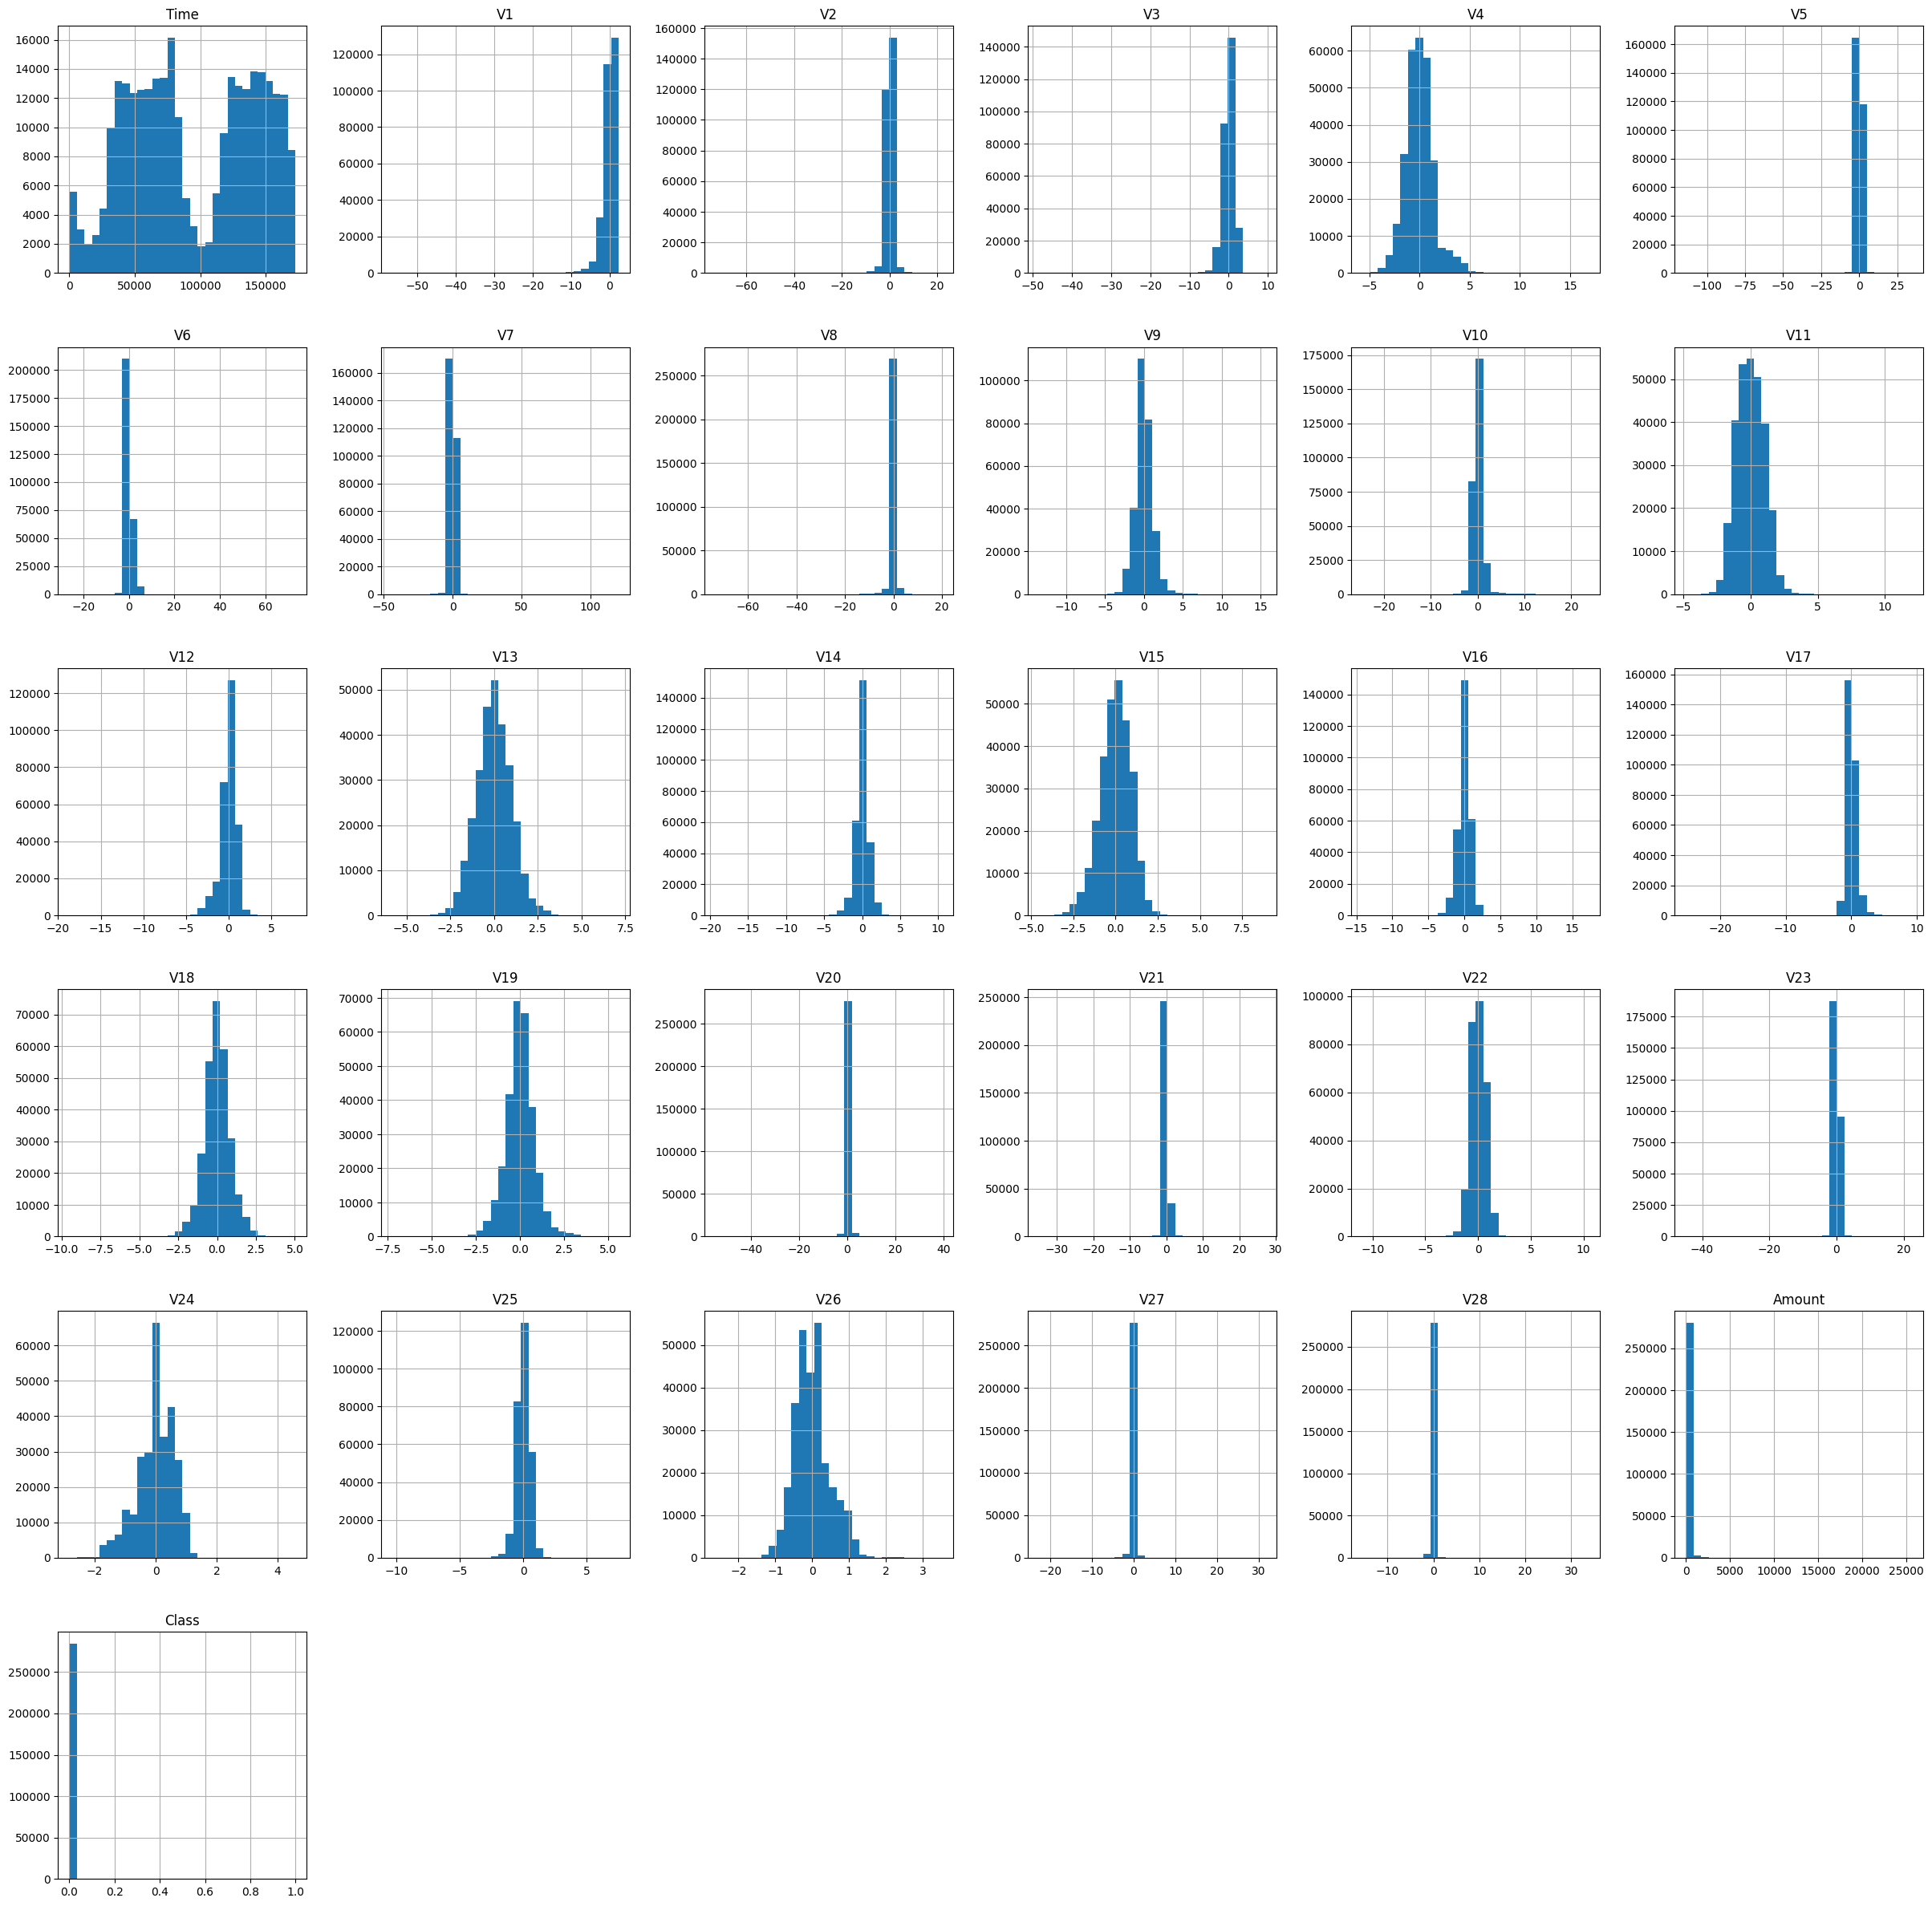

In [9]:
df.hist(bins=30, figsize=(30, 30))

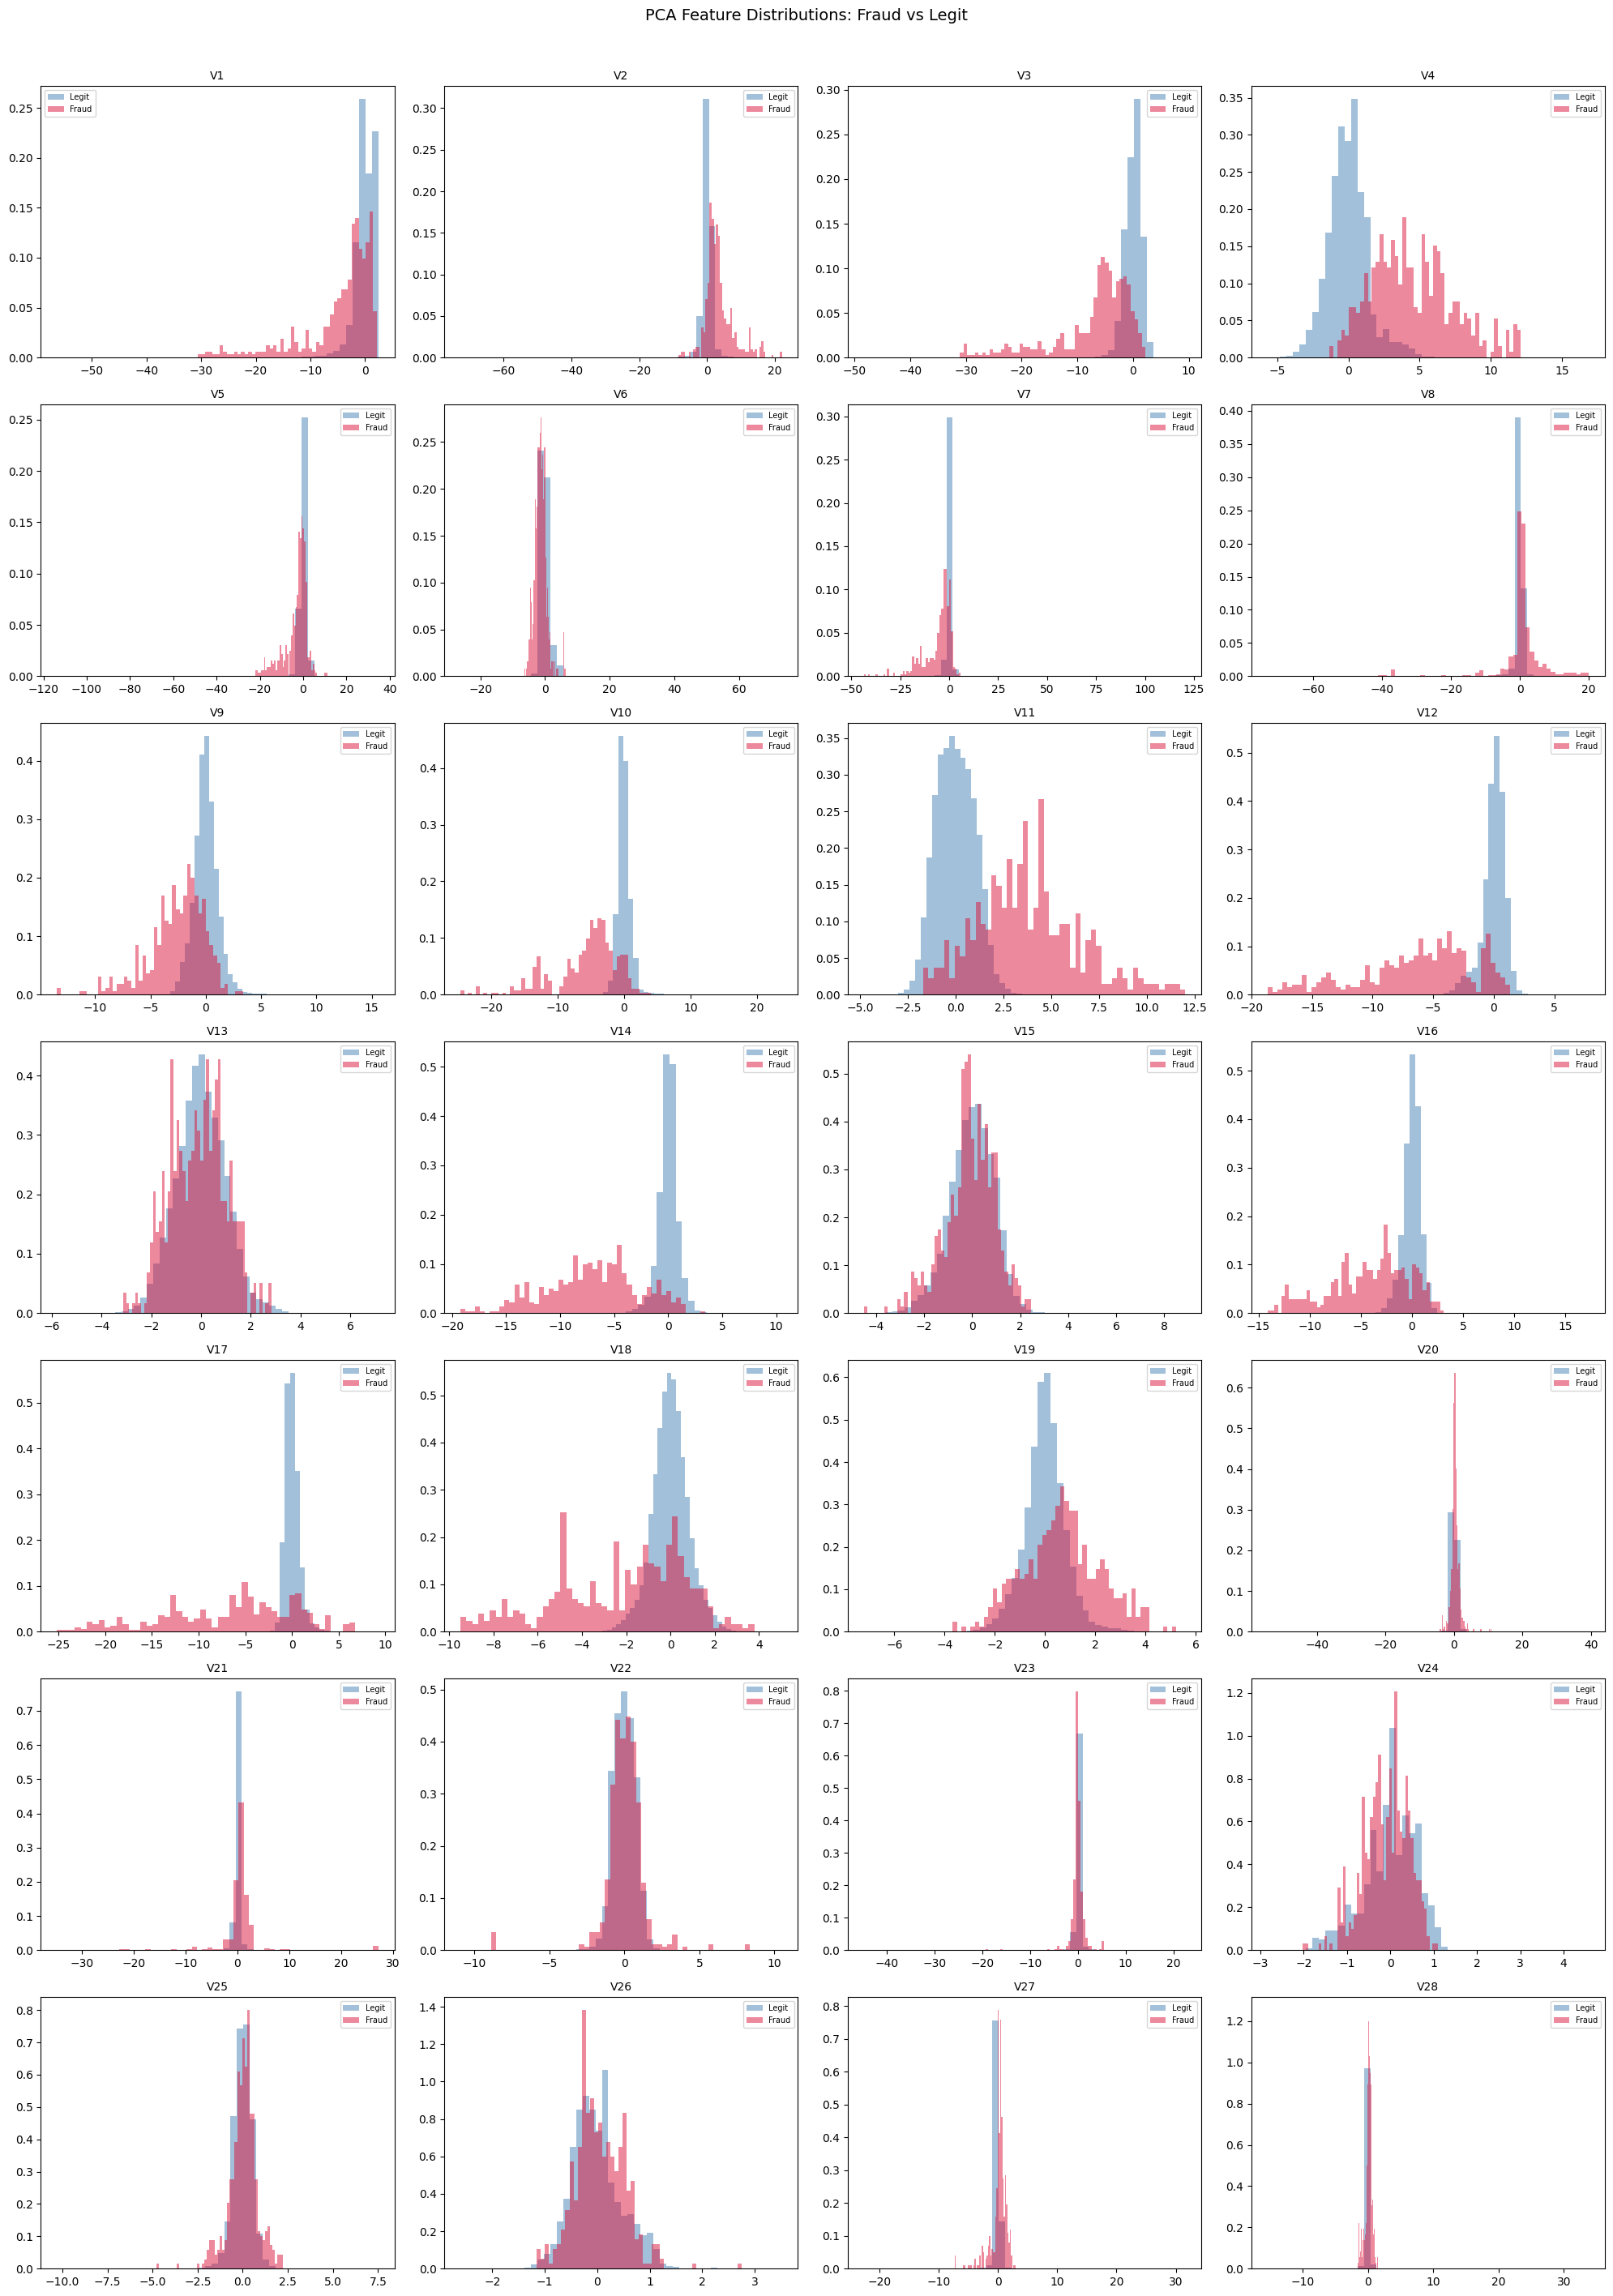

In [10]:
# --- 2.4 PCA feature distributions: fraud vs legit ---
v_features = [f'V{i}' for i in range(1, 29)]

fig, axes = plt.subplots(7, 4, figsize=(20, 28))
axes = axes.flatten()

for i, feat in enumerate(v_features):
    for label, color, name in [(0, 'steelblue', 'Legit'), (1, 'crimson', 'Fraud')]:
        axes[i].hist(df[df['Class']==label][feat], bins=50, alpha=0.5,
                     color=color, label=name, density=True)
    axes[i].set_title(feat, fontsize=10)
    axes[i].legend(fontsize=7)

plt.suptitle('PCA Feature Distributions: Fraud vs Legit', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

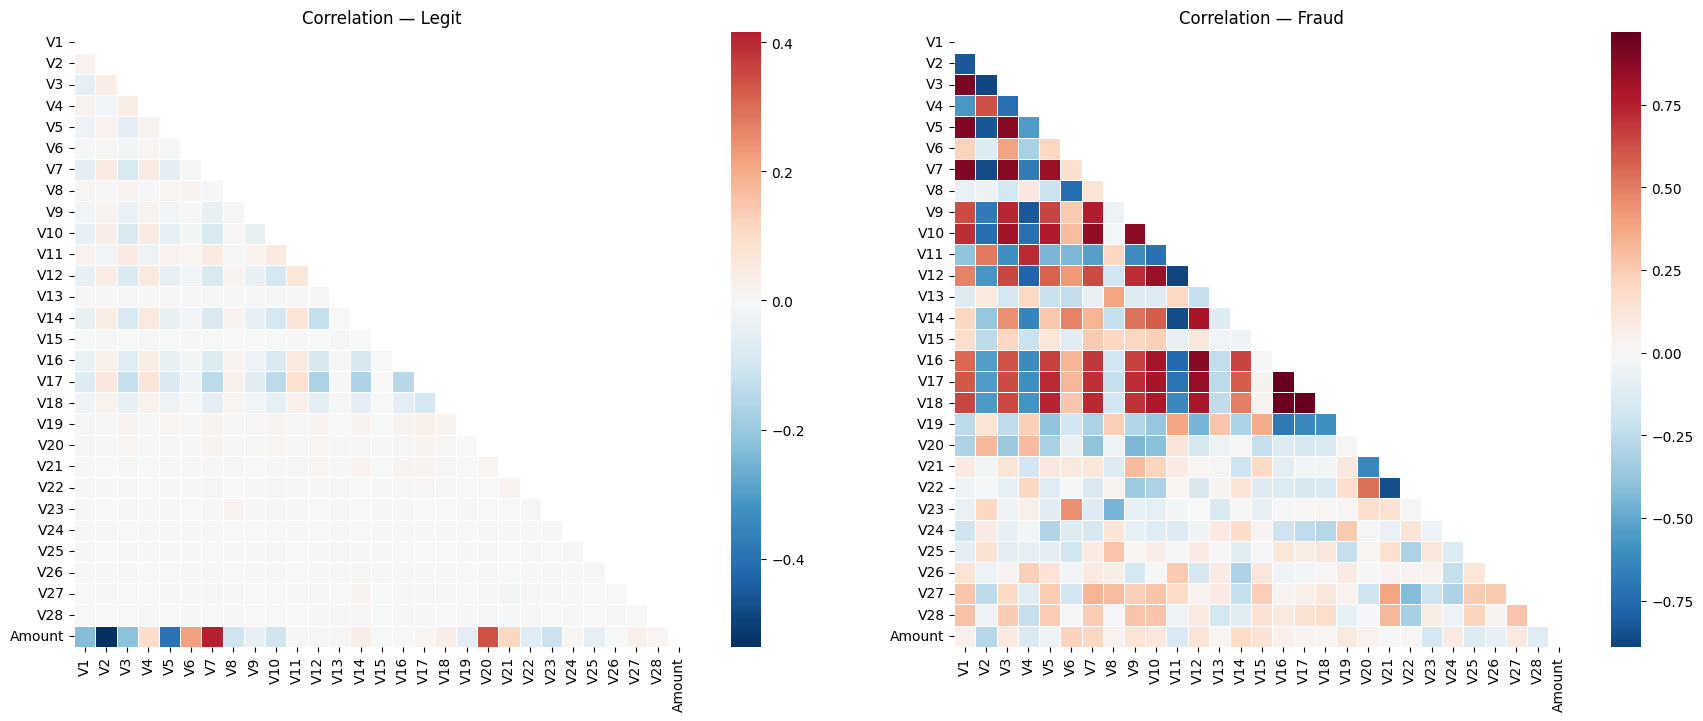

In [11]:
# --- 2.5 Correlation heatmap (fraud transactions only) ---
import seaborn as sns
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, label, title in [(axes[0], 0, 'Correlation — Legit'), (axes[1], 1, 'Correlation — Fraud')]:
    corr = df[df['Class']==label][v_features + ['Amount']].corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, ax=ax, cmap='RdBu_r', center=0,
                square=True, linewidths=0.5, annot=False, fmt='.1f')
    ax.set_title(title, fontsize=12)

plt.tight_layout()
plt.show()

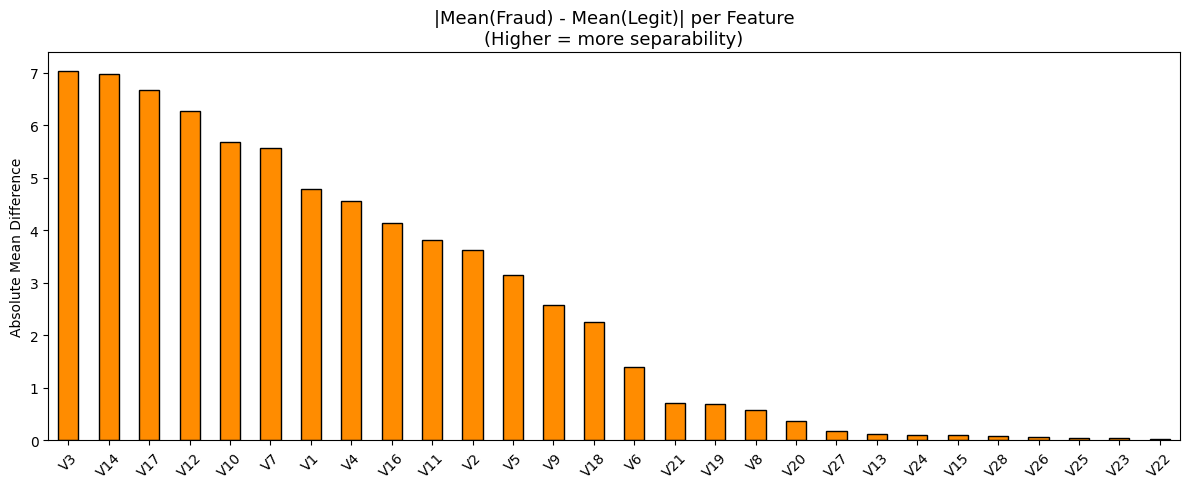

Top 10 most separating features:
V3     7.045452
V14    6.983787
V17    6.677371
V12    6.270225
V10    5.686707
V7     5.578368
V1     4.780206
V4     4.549889
V16    4.147110
V11    3.806749
dtype: float64


In [12]:
# --- 2.6 Feature importance preview: mean absolute difference between classes ---
fraud = df[df['Class']==1][v_features].mean()
legit = df[df['Class']==0][v_features].mean()
diff = (fraud - legit).abs().sort_values(ascending=False)

plt.figure(figsize=(12, 5))
diff.plot(kind='bar', color='darkorange', edgecolor='black')
plt.title('|Mean(Fraud) - Mean(Legit)| per Feature\n(Higher = more separability)', fontsize=13)
plt.ylabel('Absolute Mean Difference')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print('Top 10 most separating features:')
print(diff.head(10))

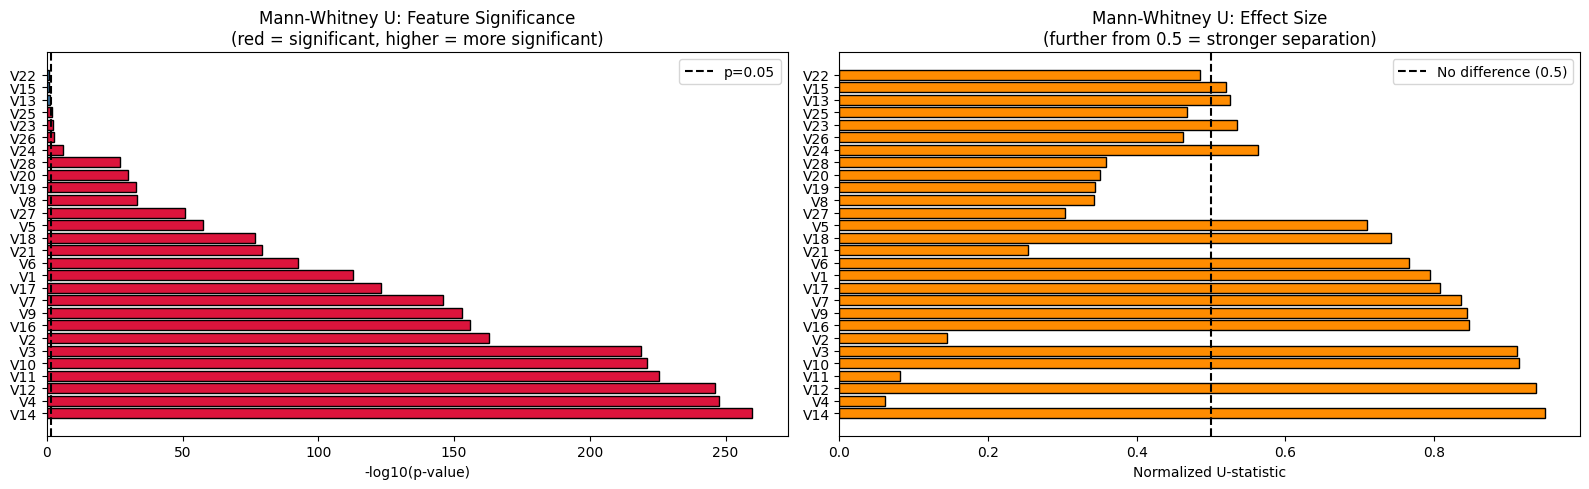

In [13]:
from scipy.stats import mannwhitneyu

results = {}
for feat in v_features:
    stat, p = mannwhitneyu(
        df[df['Class']==0][feat],
        df[df['Class']==1][feat],
        alternative='two-sided'
    )
    results[feat] = {'stat': stat, 'p_value': p}

results_df = pd.DataFrame(results).T
results_df['-log10(p)'] = -np.log10(results_df['p_value'])
results_df = results_df.sort_values('-log10(p)', ascending=False)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- Left: -log10(p-value) ---
colors = ['crimson' if p < 0.05 else 'steelblue' for p in results_df['p_value']]
axes[0].barh(results_df.index, results_df['-log10(p)'], color=colors, edgecolor='black')
axes[0].axvline(-np.log10(0.05), color='black', linestyle='--', label='p=0.05')
axes[0].set_xlabel('-log10(p-value)')
axes[0].set_title('Mann-Whitney U: Feature Significance\n(red = significant, higher = more significant)')
axes[0].legend()

# --- Right: U-statistic (normalized) ---
n0 = (df['Class']==0).sum()
n1 = (df['Class']==1).sum()
results_df['U_norm'] = results_df['stat'] / (n0 * n1)  # ranges 0-1, 0.5 = no difference
axes[1].barh(results_df.index, results_df['U_norm'], color='darkorange', edgecolor='black')
axes[1].axvline(0.5, color='black', linestyle='--', label='No difference (0.5)')
axes[1].set_xlabel('Normalized U-statistic')
axes[1].set_title('Mann-Whitney U: Effect Size\n(further from 0.5 = stronger separation)')
axes[1].legend()

plt.tight_layout()
plt.show()

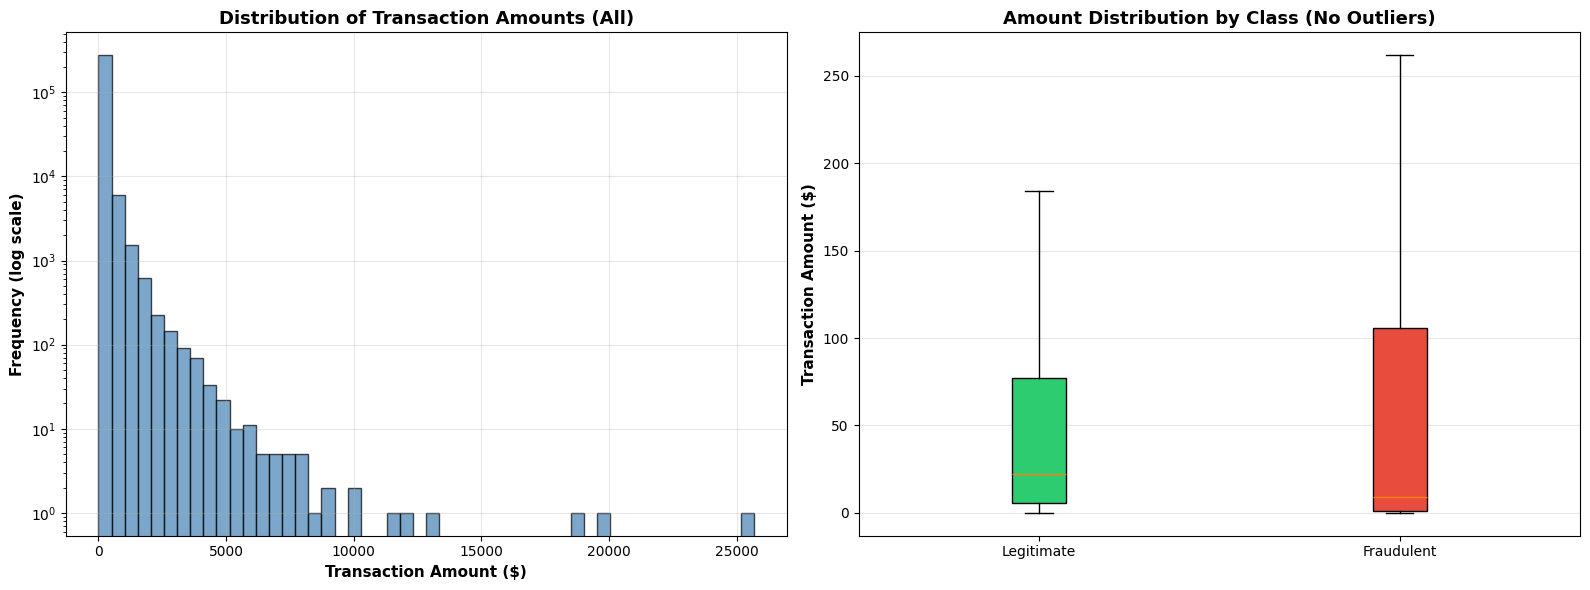

TRANSACTION AMOUNT STATISTICS
Overall - Mean: $88.35, Median: $22.00
Legitimate - Mean: $88.29, Median: $22.00
Fraudulent - Mean: $122.21, Median: $9.25


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6)) # Changed to 1 row, 2 columns, and adjusted figsize

# Overall Amount Distribution (with log scale for better visibility)
axes[0].hist(df['Amount'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Transaction Amount ($)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Frequency (log scale)', fontsize=11, fontweight='bold')
axes[0].set_title('Distribution of Transaction Amounts (All)', fontsize=13, fontweight='bold')
axes[0].set_yscale('log')
axes[0].grid(alpha=0.3)
df_legit=df[df['Class']==0]
df_fraud=df[df['Class']==1]

# Amount Distribution by Class
# Box plot comparison
box_data = [df_legit['Amount'], df_fraud['Amount']]
bp = axes[1].boxplot(box_data, tick_labels=['Legitimate', 'Fraudulent'],
                         patch_artist=True, showfliers=False)
bp['boxes'][0].set_facecolor('#2ecc71')
bp['boxes'][1].set_facecolor('#e74c3c')
axes[1].set_ylabel('Transaction Amount ($)', fontsize=11, fontweight='bold')
axes[1].set_title('Amount Distribution by Class (No Outliers)', fontsize=13, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('02_amount_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# Print statistics
print("="*80)
print("TRANSACTION AMOUNT STATISTICS")
print("="*80)
print(f"Overall - Mean: ${df['Amount'].mean():.2f}, Median: ${df['Amount'].median():.2f}")
print(f"Legitimate - Mean: ${df_legit['Amount'].mean():.2f}, Median: ${df_legit['Amount'].median():.2f}")
print(f"Fraudulent - Mean: ${df_fraud['Amount'].mean():.2f}, Median: ${df_fraud['Amount'].median():.2f}")
print("="*80)

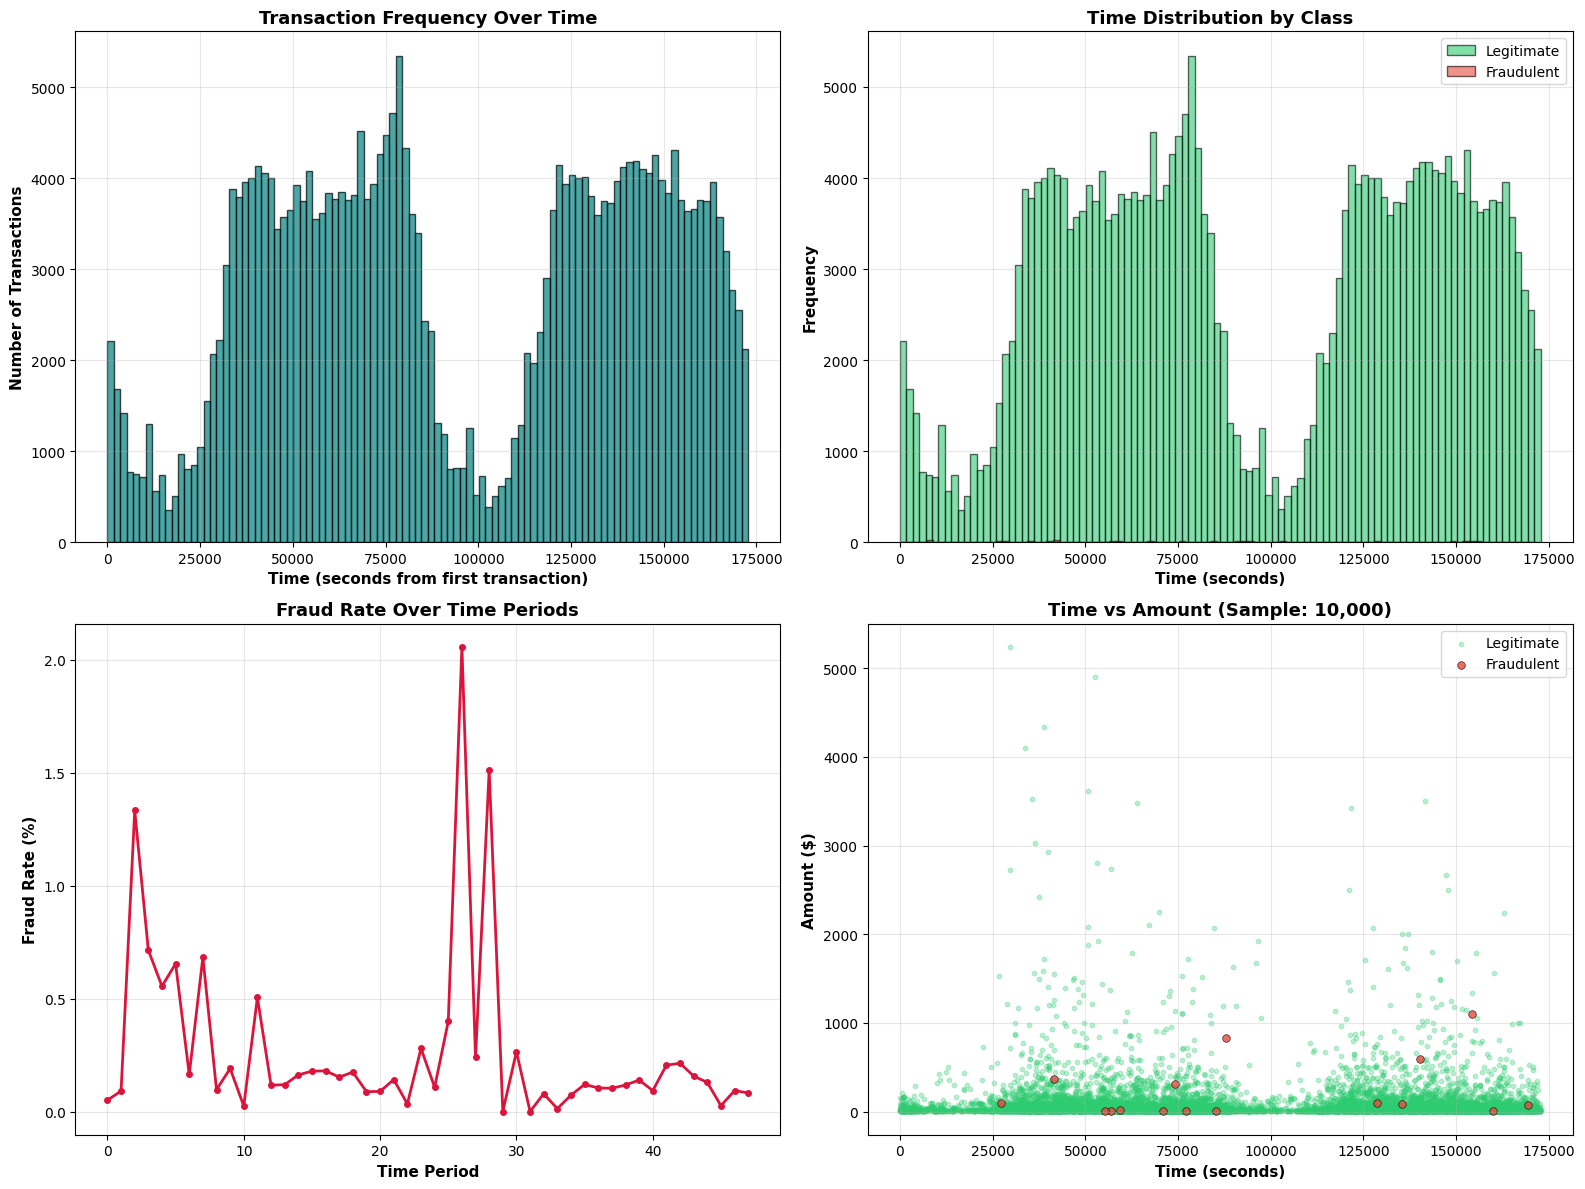

 Time distribution analysis complete!


In [15]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Transaction frequency over time
axes[0, 0].hist(df['Time'], bins=100, color='teal', edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Time (seconds from first transaction)', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('Number of Transactions', fontsize=11, fontweight='bold')
axes[0, 0].set_title('Transaction Frequency Over Time', fontsize=13, fontweight='bold')
axes[0, 0].grid(alpha=0.3)

# Time distribution by class
axes[0, 1].hist(df_legit['Time'], bins=100, alpha=0.6, label='Legitimate',
                color='#2ecc71', edgecolor='black')
axes[0, 1].hist(df_fraud['Time'], bins=100, alpha=0.6, label='Fraudulent',
                color='#e74c3c', edgecolor='black')
axes[0, 1].set_xlabel('Time (seconds)', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[0, 1].set_title('Time Distribution by Class', fontsize=13, fontweight='bold')
axes[0, 1].legend(fontsize=10)
axes[0, 1].grid(alpha=0.3)

# Fraud rate over time periods
time_bins = pd.cut(df['Time'], bins=48)
fraud_rate_time = df.groupby(time_bins)['Class'].agg(['mean', 'count'])
fraud_rate_time['fraud_pct'] = fraud_rate_time['mean'] * 100

axes[1, 0].plot(range(len(fraud_rate_time)), fraud_rate_time['fraud_pct'],
                marker='o', linewidth=2, markersize=4, color='crimson')
axes[1, 0].set_xlabel('Time Period', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Fraud Rate (%)', fontsize=11, fontweight='bold')
axes[1, 0].set_title('Fraud Rate Over Time Periods', fontsize=13, fontweight='bold')
axes[1, 0].grid(alpha=0.3)

# Scatter: Time vs Amount (sample for clarity)
sample_size = min(10000, len(df))
df_sample = df.sample(n=sample_size, random_state=42)
scatter_legit = df_sample[df_sample['Class'] == 0]
scatter_fraud = df_sample[df_sample['Class'] == 1]

axes[1, 1].scatter(scatter_legit['Time'], scatter_legit['Amount'],
                   alpha=0.3, s=10, c='#2ecc71', label='Legitimate')
axes[1, 1].scatter(scatter_fraud['Time'], scatter_fraud['Amount'],
                   alpha=0.8, s=30, c='#e74c3c', label='Fraudulent',
                   edgecolors='black', linewidth=0.5)
axes[1, 1].set_xlabel('Time (seconds)', fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel('Amount ($)', fontsize=11, fontweight='bold')
axes[1, 1].set_title(f'Time vs Amount (Sample: {sample_size:,})', fontsize=13, fontweight='bold')
axes[1, 1].legend(fontsize=10)
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('03_time_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(" Time distribution analysis complete!")

# DataPreprocessing

<Axes: >

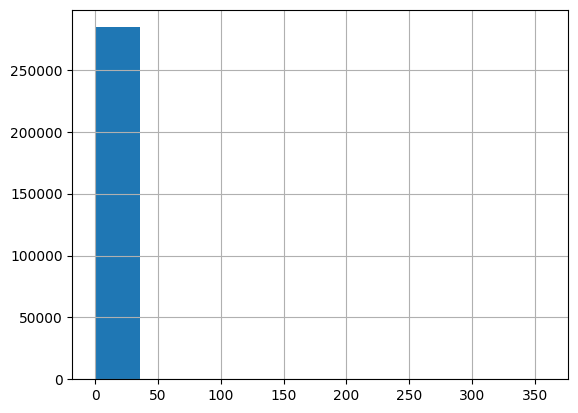

In [16]:
#Amount ranges from 0 to 25691.160000

from sklearn.preprocessing import RobustScaler, StandardScaler
new_df = df.copy()
new_df['Amount'] = RobustScaler().fit_transform(new_df['Amount'].to_numpy().reshape(-1, 1))
new_df['Amount'].hist()

In [17]:
new_df['Amount'].describe()

count    284807.000000
mean          0.927124
std           3.495006
min          -0.307413
25%          -0.229162
50%           0.000000
75%           0.770838
max         358.683155
Name: Amount, dtype: float64

In [18]:
time = new_df['Time']
#standard scaler
new_df['Time'] = StandardScaler().fit_transform(new_df[['Time']])
new_df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-1.996583,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,1.783274,0
1,-1.996583,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,-0.269825,0
2,-1.996562,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,4.983721,0
3,-1.996562,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,1.418291,0
4,-1.996541,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0.670579,0


In [19]:
new_df = new_df.sample(frac=1, random_state=42)
new_df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
43428,-1.122574,-16.526507,8.584972,-18.649853,9.505594,-13.793819,-2.832404,-16.701694,7.517344,-8.507059,...,1.190739,-1.127670,-2.358579,0.673461,-1.413700,-0.462762,-2.018575,-1.042804,4.781527,1
49906,-1.064538,0.339812,-2.743745,-0.134070,-1.385729,-1.451413,1.015887,-0.524379,0.224060,0.899746,...,-0.213436,-0.942525,-0.526819,-1.156992,0.311211,-0.746647,0.040996,0.102038,6.960386,0
29474,-1.249364,1.399590,-0.590701,0.168619,-1.029950,-0.539806,0.040444,-0.712567,0.002299,-0.971747,...,0.102398,0.168269,-0.166639,-0.810250,0.505083,-0.232340,0.011409,0.004634,0.125760,0
276481,1.522680,-0.432071,1.647895,-1.669361,-0.349504,0.785785,-0.630647,0.276990,0.586025,-0.484715,...,0.358932,0.873663,-0.178642,-0.017171,-0.207392,-0.157756,-0.237386,0.001934,-0.286453,0
278846,1.551109,2.014160,-0.137394,-1.015839,0.327269,-0.182179,-0.956571,0.043241,-0.160746,0.363241,...,-0.238644,-0.616400,0.347045,0.061561,-0.360196,0.174730,-0.078043,-0.070571,-0.294977,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119879,-0.404225,1.173488,0.100792,0.490512,0.461596,-0.296377,-0.213165,-0.165254,0.119221,-0.114199,...,-0.186027,-0.574283,0.161405,-0.006140,0.091444,0.109235,-0.020922,0.003967,-0.279746,0
259178,1.351627,-0.775981,0.144023,-1.142399,-1.241113,1.940358,3.912076,-0.466107,1.360620,0.400697,...,0.037078,-0.019575,0.241830,0.682820,-1.635109,-0.770941,0.066006,0.137056,0.939426,0
131932,-0.316266,-0.146609,0.992946,1.524591,0.485774,0.349308,-0.815198,1.076640,-0.395316,-0.491303,...,0.052649,0.354089,-0.291198,0.402849,0.237383,-0.398467,-0.121139,-0.196195,-0.252358,0
146867,-0.144939,-2.948638,2.354849,-2.521201,-3.798905,1.866302,2.727695,-0.471769,2.217537,0.580199,...,-0.332759,-1.047514,0.143326,0.678869,0.319710,0.426309,0.496912,0.335822,-0.293440,0


In [20]:
from sklearn.model_selection import train_test_split

train, temp = train_test_split(
    new_df,
    test_size=0.2,
    stratify=new_df['Class'],
    random_state=42
)

test, val = train_test_split(
    temp,
    test_size=0.5,
    stratify=temp['Class'],
    random_state=42
)

In [21]:
x_train = train.drop(columns=['Class'])
y_train = train['Class']

x_test = test.drop(columns=['Class'])
y_test = test['Class']

x_val = val.drop(columns=['Class'])
y_val = val['Class']

x_train.shape, y_train.shape, x_test.shape, y_test.shape, x_val.shape, y_val.shape

((227845, 30), (227845,), (28481, 30), (28481,), (28481, 30), (28481,))

# XGBoost

In [22]:
pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 11.2 MB/s eta 0:00:00 0:00:01

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip3.11 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [23]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

scale_pos_weight = neg / pos

In [24]:
from xgboost import XGBClassifier

# Calculate pos_weight using the already defined neg and pos counts
pos_weight = neg / pos

xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=4,
    scale_pos_weight=pos_weight,
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(x_train, y_train)

# Validation predictions
y_pred = xgb.predict(x_val)
y_proba = xgb.predict_proba(x_val)[:, 1]


XGBoostError: 
XGBoost Library (libxgboost.dylib) could not be loaded.
Likely causes:
  * OpenMP runtime is not installed
    - vcomp140.dll or libgomp-1.dll for Windows
    - libomp.dylib for Mac OSX
    - libgomp.so for Linux and other UNIX-like OSes
    Mac OSX users: Run `brew install libomp` to install OpenMP runtime.

  * You are running 32-bit Python on a 64-bit OS

Error message(s): ["dlopen(/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/xgboost/lib/libxgboost.dylib, 0x0006): Library not loaded: @rpath/libomp.dylib\n  Referenced from: <1A0D8152-BF46-3BE0-B651-EE965C187777> /Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/xgboost/lib/libxgboost.dylib\n  Reason: tried: '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/O

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, average_precision_score
print(confusion_matrix(y_val, y_pred))
print(classification_report(y_val, y_pred))
pr_auc = average_precision_score(y_val, y_proba)
print("Validation PR-AUC:", pr_auc)

[[28421    11]
 [    9    40]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     28432
           1       0.78      0.82      0.80        49

    accuracy                           1.00     28481
   macro avg       0.89      0.91      0.90     28481
weighted avg       1.00      1.00      1.00     28481

Validation PR-AUC: 0.8055327186066918


In [ ]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_val, y_proba)
print("ROC-AUC:", roc_auc)

ROC-AUC: 0.9548654577193849


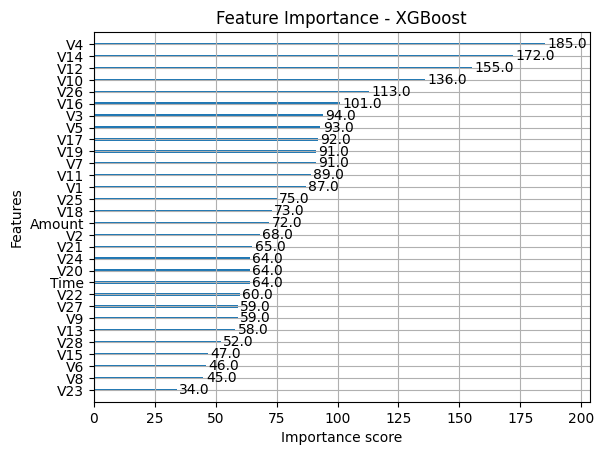

In [ ]:
import matplotlib.pyplot as plt
from xgboost import plot_importance
plot_importance(xgb)
plt.title("Feature Importance - XGBoost")
plt.show()

In [ ]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    xgb,
    x_train,
    y_train,
    cv=5,
    scoring="average_precision"
)

print("Cross-validated PR-AUC:", cv_scores.mean())

Cross-validated PR-AUC: 0.8427206802418775


Cross-validation was performed using PR-AUC (average precision) as the scoring metric because the dataset is highly imbalanced. The model achieved a mean cross-validated PR-AUC of 0.84, indicating strong ability to identify fraudulent transactions.

# Hyperparameter Tuning for XGBoost

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "n_estimators":[100,200,300],
    "max_depth":[3,4,6,8],
    "learning_rate":[0.01,0.05,0.1],
    "subsample":[0.8,1],
    "colsample_bytree":[0.8,1]
}

search = RandomizedSearchCV(
    XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        eval_metric="logloss",
        random_state=42
    ),
    param_distributions=param_dist,
    n_iter=10,
    scoring="average_precision",
    cv=3,
    n_jobs=-1,
    random_state=42
)

search.fit(x_train, y_train)

print("Best PR-AUC:", search.best_score_)
print("Best Params:", search.best_params_)

Best PR-AUC: 0.8600115121855771
Best Params: {'subsample': 0.8, 'n_estimators': 100, 'max_depth': 8, 'learning_rate': 0.1, 'colsample_bytree': 0.8}


Evaluate Tuned XGBoost Model on Validation Set

In [ ]:
best_xgb = search.best_estimator_

best_xgb.fit(x_train, y_train)

y_pred = best_xgb.predict(x_val)
y_proba = best_xgb.predict_proba(x_val)[:,1]

from sklearn.metrics import average_precision_score
print("Validation PR-AUC:", average_precision_score(y_val, y_proba))

Validation PR-AUC: 0.829460523176265


Hyperparameter tuning improved cross-validated PR-AUC to 0.86.
The tuned model achieved 0.829 PR-AUC on the validation set, indicating strong generalization performance for fraud detection.

SMOTE

In [ ]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.metrics import average_precision_score

smote_pipeline = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("xgb", XGBClassifier(
        eval_metric="logloss",
        random_state=42
    ))
])

smote_pipeline.fit(x_train, y_train)

y_pred_smote = smote_pipeline.predict(x_val)
y_proba_smote = smote_pipeline.predict_proba(x_val)[:,1]

print("SMOTE Validation PR-AUC:",
      average_precision_score(y_val, y_proba_smote))

SMOTE Validation PR-AUC: 0.813250382087734


An experiment was conducted using SMOTE to handle class imbalance. The model trained with SMOTE achieved a validation PR-AUC of 0.813, which is slightly lower than the tuned XGBoost model that used scale_pos_weight, which achieved a validation PR-AUC of 0.829. Therefore, the scale_pos_weight approach was selected as the final model for fraud detection.

In [ ]:
from sklearn.metrics import precision_recall_curve, classification_report
import numpy as np

#Threshold tuning the XGBoost Model
precision, recall, thresholds = precision_recall_curve(y_val, y_proba)

#choose threshold that maximizes F1
f1 = 2 * (precision * recall) / (precision + recall + 1e-9)
best_idx = np.argmax(f1)
best_threshold = thresholds[best_idx]

print("Best threshold:", best_threshold)

print("After tuning threshold.. ")
y_pred_tuned = (y_proba >= best_threshold).astype(int)
print(classification_report(y_val, y_pred_tuned))

Best threshold: 0.92449063
After tuning threshold.. 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     28432
           1       0.93      0.78      0.84        49

    accuracy                           1.00     28481
   macro avg       0.96      0.89      0.92     28481
weighted avg       1.00      1.00      1.00     28481



In [ ]:
print("Default threshold (0.5):")
print(classification_report(y_val, (y_proba >= 0.5).astype(int)))

print("Optimized threshold:")
print(classification_report(y_val, y_pred_tuned))

Default threshold (0.5):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     28432
           1       0.87      0.80      0.83        49

    accuracy                           1.00     28481
   macro avg       0.93      0.90      0.91     28481
weighted avg       1.00      1.00      1.00     28481

Optimized threshold:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     28432
           1       0.93      0.78      0.84        49

    accuracy                           1.00     28481
   macro avg       0.96      0.89      0.92     28481
weighted avg       1.00      1.00      1.00     28481



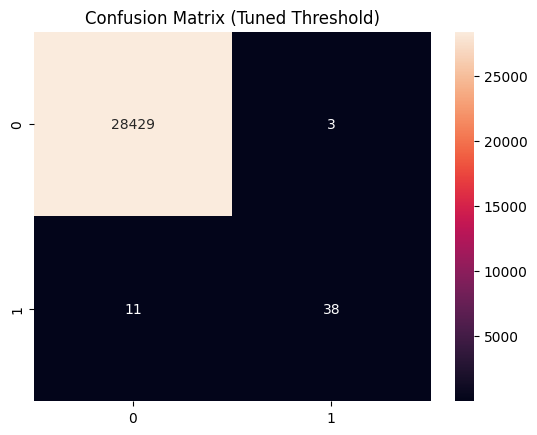

In [ ]:
import seaborn as sns

cm = confusion_matrix(y_val, y_pred_tuned)
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix (Tuned Threshold)")
plt.show()

# Risk Scoring Framework

Convert probabilities to risk score

In [ ]:
risk_score = (y_proba * 100).round(2)

Create a dataframe

In [ ]:
import pandas as pd

risk_df = pd.DataFrame({
    "Fraud_Probability": y_proba,
    "Risk_Score": risk_score
})

risk_df.head()

,Fraud_Probability,Risk_Score
0,0.000058,0.01
1,0.000232,0.02
2,0.000082,0.01
3,0.000064,0.01
4,0.000144,0.01


Assign risk tiers

In [ ]:
def assign_risk(score):

    if score <= 30:
        return "Low"
    elif score <= 60:
        return "Medium"
    elif score <= 85:
        return "High"
    else:
        return "Critical"

risk_df["Risk_Level"] = risk_df["Risk_Score"].apply(assign_risk)

In [ ]:
def assign_action(level):

    if level == "Low":
        return "Auto-approve"
    elif level == "Medium":
        return "Allow but monitor"
    elif level == "High":
        return "Step-up authentication"
    else:
        return "Auto-decline / analyst review"

risk_df["Recommended_Action"] = risk_df["Risk_Level"].apply(assign_action)

risk_df.head()

,Fraud_Probability,Risk_Score,Risk_Level,Recommended_Action
0,0.000058,0.01,Low,Auto-approve
1,0.000232,0.02,Low,Auto-approve
2,0.000082,0.01,Low,Auto-approve
3,0.000064,0.01,Low,Auto-approve
4,0.000144,0.01,Low,Auto-approve


Risk Score Summary Table

In [ ]:
risk_summary = risk_df["Risk_Level"].value_counts().reset_index()
risk_summary.columns = ["Risk_Level", "Transaction_Count"]

risk_summary

,Risk_Level,Transaction_Count
0,Low,28433
1,Critical,42
2,Medium,3
3,High,3


Add Risk Score Distribution

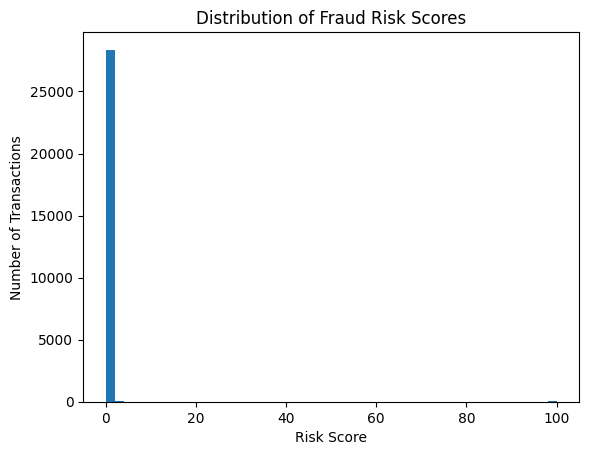

In [ ]:
import matplotlib.pyplot as plt

plt.hist(risk_df["Risk_Score"], bins=50)
plt.xlabel("Risk Score")
plt.ylabel("Number of Transactions")
plt.title("Distribution of Fraud Risk Scores")
plt.show()

Risk Level Bar Chart

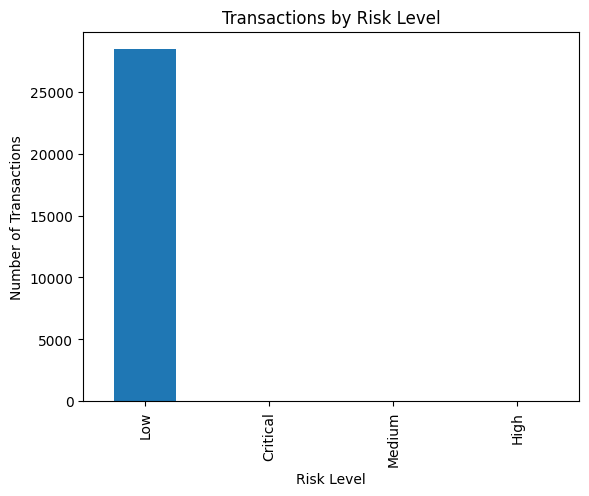

In [ ]:
risk_df["Risk_Level"].value_counts().plot(kind="bar")

plt.title("Transactions by Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Number of Transactions")
plt.show()

# Improving Recall: Three Approaches

The F1-optimal threshold (0.92) pushes precision to 0.93 but drops recall to 0.78. We try:
1. **F2-optimal threshold** — weights recall 4x more than precision
2. **RF + XGBoost ensemble** — average probabilities to catch different hard cases
3. **XGBoost + SMOTE** — oversample fraud before training

In [26]:
# Approach 1: F2-optimal threshold (favors recall over precision)
from sklearn.metrics import precision_recall_curve, classification_report, f1_score, recall_score, precision_score
from xgboost import XGBClassifier
import numpy as np

# Rebuild the tuned XGBoost from the best hyperparameters found earlier
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
best_xgb = XGBClassifier(
    n_estimators=100,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=neg / pos,
    eval_metric="logloss",
    random_state=42
)
best_xgb.fit(x_train, y_train)

y_proba_tuned = best_xgb.predict_proba(x_val)[:, 1]
prec_arr, rec_arr, thr_arr = precision_recall_curve(y_val, y_proba_tuned)
n = len(thr_arr)
eps = 1e-9

f1_arr = np.array([2*prec_arr[j+1]*rec_arr[j+1] / (prec_arr[j+1]+rec_arr[j+1]+eps) for j in range(n)])
f2_arr = np.array([5*prec_arr[j+1]*rec_arr[j+1] / (4*prec_arr[j+1]+rec_arr[j+1]+eps) for j in range(n)])

j_f1 = np.argmax(f1_arr)
j_f2 = np.argmax(f2_arr)

print("=== F1-optimal threshold ===")
thr_f1 = thr_arr[j_f1]
pred_f1 = (y_proba_tuned >= thr_f1).astype(int)
print(f"Threshold = {thr_f1:.4f}")
print(classification_report(y_val, pred_f1))

print("=== F2-optimal threshold (favors recall) ===")
thr_f2 = thr_arr[j_f2]
pred_f2 = (y_proba_tuned >= thr_f2).astype(int)
print(f"Threshold = {thr_f2:.4f}")
print(classification_report(y_val, pred_f2))

XGBoostError: 
XGBoost Library (libxgboost.dylib) could not be loaded.
Likely causes:
  * OpenMP runtime is not installed
    - vcomp140.dll or libgomp-1.dll for Windows
    - libomp.dylib for Mac OSX
    - libgomp.so for Linux and other UNIX-like OSes
    Mac OSX users: Run `brew install libomp` to install OpenMP runtime.

  * You are running 32-bit Python on a 64-bit OS

Error message(s): ["dlopen(/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/xgboost/lib/libxgboost.dylib, 0x0006): Library not loaded: @rpath/libomp.dylib\n  Referenced from: <1A0D8152-BF46-3BE0-B651-EE965C187777> /Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/xgboost/lib/libxgboost.dylib\n  Reason: tried: '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/O

In [ ]:
# Approach 2: Ensemble — RF + XGBoost average probabilities
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, precision_recall_curve
import numpy as np

rf_ens = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_ens.fit(x_train, y_train)

rf_proba  = rf_ens.predict_proba(x_val)[:, 1]
xgb_proba = best_xgb.predict_proba(x_val)[:, 1]

# Weighted average: give XGBoost slightly more weight (it had better PR-AUC)
for w_xgb in [0.5, 0.6, 0.7]:
    w_rf = 1 - w_xgb
    ens_proba = w_xgb * xgb_proba + w_rf * rf_proba

    prec, rec, thr = precision_recall_curve(y_val, ens_proba)
    n = len(thr)
    eps = 1e-9
    f1 = np.array([2*prec[j+1]*rec[j+1]/(prec[j+1]+rec[j+1]+eps) for j in range(n)])
    f2 = np.array([5*prec[j+1]*rec[j+1]/(4*prec[j+1]+rec[j+1]+eps) for j in range(n)])

    j1 = np.argmax(f1)
    j2 = np.argmax(f2)

    print(f"\n=== Ensemble w_XGB={w_xgb}, w_RF={w_rf} ===")
    print(f"  F1-opt threshold = {thr[j1]:.4f}  P={prec[j1+1]:.4f}  R={rec[j1+1]:.4f}  F1={f1[j1]:.4f}")
    print(f"  F2-opt threshold = {thr[j2]:.4f}  P={prec[j2+1]:.4f}  R={rec[j2+1]:.4f}  F2={f2[j2]:.4f}")

# Show full report for best ensemble config (F2-optimal, w=0.5)
ens_proba_best = 0.5 * xgb_proba + 0.5 * rf_proba
prec, rec, thr = precision_recall_curve(y_val, ens_proba_best)
n = len(thr)
f2 = np.array([5*prec[j+1]*rec[j+1]/(4*prec[j+1]+rec[j+1]+eps) for j in range(n)])
j2 = np.argmax(f2)
thr_ens = thr[j2]
pred_ens = (ens_proba_best >= thr_ens).astype(int)
print("\n=== Best Ensemble Full Report (50/50, F2-optimal) ===")
print(f"Threshold = {thr_ens:.4f}")
print(classification_report(y_val, pred_ens))

In [ ]:
# Approach 3: XGBoost + SMOTE with tuned oversampling + class weighting
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, precision_recall_curve, average_precision_score

configs = [
    {"sampling_strategy": 0.3, "k_neighbors": 5, "scale_pos_weight": 1},
    {"sampling_strategy": 0.5, "k_neighbors": 5, "scale_pos_weight": 1},
    {"sampling_strategy": 0.3, "k_neighbors": 3, "scale_pos_weight": neg/pos},
    {"sampling_strategy": 0.5, "k_neighbors": 7, "scale_pos_weight": neg/pos},
]

best_recall_overall = 0
best_config_label = ""
best_threshold = 0.5
best_predictions = None

for i, cfg in enumerate(configs):
    pipe = ImbPipeline([
        ("smote", SMOTE(
            sampling_strategy=cfg["sampling_strategy"],
            k_neighbors=cfg["k_neighbors"],
            random_state=42
        )),
        ("xgb", XGBClassifier(
            n_estimators=300,
            max_depth=6,
            learning_rate=0.1,
            scale_pos_weight=cfg["scale_pos_weight"],
            eval_metric="logloss",
            random_state=42
        ))
    ])
    pipe.fit(x_train, y_train)
    proba = pipe.predict_proba(x_val)[:, 1]

    prec, rec, thr = precision_recall_curve(y_val, proba)
    n = len(thr)
    eps = 1e-9
    f2 = np.array([5*prec[j+1]*rec[j+1]/(4*prec[j+1]+rec[j+1]+eps) for j in range(n)])
    j2 = np.argmax(f2)

    label = f"SMOTE({cfg['sampling_strategy']}, k={cfg['k_neighbors']}) + scale_pos_weight={cfg['scale_pos_weight']:.1f}"
    print(f"\n--- Config {i+1}: {label} ---")
    print(f"  PR-AUC = {average_precision_score(y_val, proba):.4f}")
    print(f"  F2-opt threshold = {thr[j2]:.4f}  P={prec[j2+1]:.4f}  R={rec[j2+1]:.4f}  F2={f2[j2]:.4f}")

    if rec[j2+1] > best_recall_overall:
        best_recall_overall = rec[j2+1]
        best_config_label = label
        best_threshold = thr[j2]
        best_predictions = (proba >= thr[j2]).astype(int)

print(f"\n=== Best SMOTE+XGBoost Config: {best_config_label} ===")
print(f"Threshold = {best_threshold:.4f}  Recall = {best_recall_overall:.4f}")
print(classification_report(y_val, best_predictions))

In [ ]:
# Summary comparison of all approaches
import pandas as pd

summary_rows = []

def add_result(name, y_true, y_pred):
    r = recall_score(y_true, y_pred)
    p = precision_score(y_true, y_pred)
    f = f1_score(y_true, y_pred)
    summary_rows.append({"Approach": name, "Precision": round(p,4), "Recall": round(r,4), "F1": round(f,4)})

# 1) Tuned XGBoost — F1-optimal threshold
add_result("XGBoost (F1-opt thr)", y_val, pred_f1)

# 2) Tuned XGBoost — F2-optimal threshold
add_result("XGBoost (F2-opt thr)", y_val, pred_f2)

# 3) Ensemble RF+XGBoost — F2-optimal
add_result("Ensemble RF+XGB (F2-opt)", y_val, pred_ens)

# 4) Best SMOTE+XGBoost — F2-optimal
add_result("SMOTE+XGBoost (best, F2-opt)", y_val, best_predictions)

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.sort_values("Recall", ascending=False).reset_index(drop=True)
print(summary_df.to_string(index=False))